# Notebook 5: Supplementary Analysis

Produces the remaining figures and tables from the thesis appendix that extend the core demographic mixing analysis.

**Inputs** from `../data/processed/`:
- `user_graph_{key}.pkl` — user-user LCC graphs (with ideology and demographic node attributes)
- `filtered_users_{key}.pkl` — user DataFrames (connected to event-event LCC)
- `filtered_events_{key}.pkl` — event DataFrames (LCC only)
- `dropped_events_summary.pkl`, `dropped_users_summary.pkl` — component analysis summaries

**Outputs** (displayed inline, saved to `../data/processed/`):
- Tables E.6, E.7 — subgroup co-attendance with ideological right
- Figures 7.6, 7.7 — subgroup deviation over time (8 demographic groups)
- Figure E.4 — deviation by gender and heritage (2×2 panels)
- Figures 7.8, E.5–E.8 — KDE plots: ego vs average alter ideology
- Table E.2 — user network basic statistics

**Pipeline**
1. Compute expected % R baselines per dataset
2. Subgroup co-attendance: 8 groups (heritage × gender × ideology) vs ideological right
3. Gender and heritage breakdown of R co-attendance (for Figure E.4)
4. KDE plots: ego ideology vs weighted-average alter ideology
5. User network basic statistics (Table E.2)

> **Runtime note**: The Louvain community detection in Section 5 is slow on medium user networks (190k nodes, 12M edges). All other sections run in a few minutes.

In [1]:
import pickle
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(rc={"lines.linewidth": 2.3}, font_scale=1.7)
sns.set_style("whitegrid")

DATA_DIR = Path('../data/processed')

KEYS = [
    'small_2013-2014', 'small_2014-2015', 'small_2015-2016', 'small_2016-2017',
    'medium_2013-2014', 'medium_2014-2015', 'medium_2015-2016', 'medium_2016-2017',
]

YEARS          = np.array([2014, 2015, 2016, 2017])
ELECTION_YEAR  = 2015.5
SHADING_RANGES = [2013.5, 2014.5, 2015.5, 2016.5, 2017.5]
SHADES         = ["#f0f0f0", "#d0d0d0"]

## 1. Load Inputs

In [2]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

user_graphs     = {k: load_pkl(DATA_DIR / f'user_graph_{k}.pkl')       for k in KEYS}
filtered_users  = {k: pd.read_pickle(DATA_DIR / f'filtered_users_{k}.pkl')  for k in KEYS}
filtered_events = {k: pd.read_pickle(DATA_DIR / f'filtered_events_{k}.pkl') for k in KEYS}

print("Loaded all inputs.")

# Verify node attributes are present
sample_G = user_graphs['small_2013-2014']
sample_node, sample_attrs = next(iter(sample_G.nodes(data=True)))
print(f"\nSample user node attributes: {list(sample_attrs.keys())}")

Loaded all inputs.

Sample user node attributes: ['bipartite', 'gender_label', 'heritage_label', 'normalized_min_max', 'l_r_min_max', 'political']


## 2. Expected % R Baselines

The expected fraction of right-leaning co-attendees is the share of events attended by R users in the overall population (weighted by events attended, not user count).

In [3]:
def expected_r_pct(users_df):
    """Expected % R among political co-attendees.
    
    Computed as: R events attended / (L + R events attended)
    weighted by events_attended so frequent attendees count more.
    """
    l_events = users_df.loc[users_df['l_r_min_max'] == 'L', 'events_attended'].sum()
    r_events = users_df.loc[users_df['l_r_min_max'] == 'R', 'events_attended'].sum()
    total    = l_events + r_events
    return float(r_events / total * 100) if total > 0 else 0.0


expected_r = {k: expected_r_pct(filtered_users[k]) for k in KEYS}

print("Expected % R by dataset:")
for k, v in expected_r.items():
    print(f"  {k}: {v:.2f}%")

Expected % R by dataset:
  small_2013-2014: 17.85%
  small_2014-2015: 19.34%
  small_2015-2016: 18.29%
  small_2016-2017: 17.94%
  medium_2013-2014: 16.89%
  medium_2014-2015: 17.41%
  medium_2015-2016: 17.19%
  medium_2016-2017: 17.92%


## 3. Subgroup Co-attendance with Ideological Right

For each of the 8 demographic subgroups (Danish/Non-Danish × M/F × L/R), measures the fraction of political co-attendees who are right-leaning and how this deviates from the expected baseline.

Produces Tables E.6 (small events) and E.7 (medium events).

In [4]:

VALID_HERITAGE  = {'Danish', 'Non-Danish'}
VALID_GENDER    = {'M', 'F'}
VALID_IDEOLOGY  = {'L', 'R'}

def compute_subgroup_stats(G, expected_r_pct):
    """Compute co-attendance with R users for each of the 8 demographic subgroups.

    For each user in the subgroup, computes that user's individual % L and % R
    among their political co-attendees, then averages across all users in the group.
    This matches Code3's per-user-mean approach (not interactions-weighted).
    """
    # {subgroup: {total_interactions, non_pol_pct_sum, l_pct_sum, r_pct_sum, count}}
    group_accum = {}

    for user in G.nodes():
        attrs    = G.nodes[user]
        heritage = attrs.get('heritage_label')
        gender   = attrs.get('gender_label')
        ideology = attrs.get('l_r_min_max')

        if heritage not in VALID_HERITAGE or gender not in VALID_GENDER or ideology not in VALID_IDEOLOGY:
            continue

        subgroup = f"{heritage}-{gender}-{ideology}"

        total_w = non_pol_w = l_w = r_w = 0
        for nbr, edge_data in G[user].items():
            nbr_ideology = G.nodes[nbr].get('l_r_min_max', 'Non-political')
            w = edge_data.get('weight', 1)
            total_w += w
            if nbr_ideology == 'L':
                l_w += w
            elif nbr_ideology == 'R':
                r_w += w
            else:
                non_pol_w += w

        political_w = l_w + r_w
        if total_w == 0 or political_w == 0:
            continue

        # Per-user percentages
        pct_non_pol = non_pol_w / total_w * 100
        pct_l       = l_w / political_w * 100
        pct_r       = r_w / political_w * 100

        acc = group_accum.setdefault(subgroup,
              {'total': 0, 'non_pol_sum': 0, 'l_sum': 0, 'r_sum': 0, 'count': 0})
        acc['total']       += total_w
        acc['non_pol_sum'] += pct_non_pol
        acc['l_sum']       += pct_l
        acc['r_sum']       += pct_r
        acc['count']       += 1

    rows = []
    for subgroup, a in group_accum.items():
        n = a['count']
        if n == 0:
            continue
        avg_r   = a['r_sum'] / n
        avg_l   = a['l_sum'] / n
        avg_np  = a['non_pol_sum'] / n
        rows.append({
            'Subgroup':              subgroup,
            'Total Interactions':    a['total'],
            '% Non-political':       round(avg_np, 2),
            '% L':                   round(avg_l, 2),
            '% R':                   round(avg_r, 2),
            '% R Deviation':         round(avg_r - expected_r_pct, 2),
        })

    df = pd.DataFrame(rows)
    df['_sort'] = df['Subgroup'].apply(lambda s: (s.split('-')[2], s.split('-')[0], s.split('-')[1]))
    return df.sort_values('_sort').drop('_sort', axis=1).reset_index(drop=True)


subgroup_stats = {}
for key in KEYS:
    print(f"{key}...")
    subgroup_stats[key] = compute_subgroup_stats(user_graphs[key], expected_r[key])

print("\nDone. Sample (small_2013-2014):")
print(subgroup_stats['small_2013-2014'].to_string(index=False))


small_2013-2014...


small_2014-2015...


small_2015-2016...

small_2016-2017...


medium_2013-2014...


medium_2014-2015...


medium_2015-2016...


medium_2016-2017...



Done. Sample (small_2013-2014):
      Subgroup  Total Interactions  % Non-political   % L   % R  % R Deviation
Non-Danish-F-R               12404            71.68 65.77 34.23          16.39
Non-Danish-F-L               84989            71.73 86.94 13.06          -4.78
    Danish-F-L              117100            71.33 86.64 13.36          -4.49
    Danish-M-L               93928            71.21 87.04 12.96          -4.88
Non-Danish-M-L               58298            71.35 86.03 13.97          -3.87
Non-Danish-M-R               18890            70.95 58.89 41.11          23.27
    Danish-F-R               21030            69.75 64.54 35.46          17.62
    Danish-M-R               29770            71.29 59.14 40.86          23.02


In [5]:
# Build Table E.6 (small events) and Table E.7 (medium events)

def build_subgroup_table(size_label):
    dfs = []
    for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
        key = f'{size_label}_{period}'
        df  = subgroup_stats[key].copy()
        df.insert(0, 'Time Period', period)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

table_e6 = build_subgroup_table('small')
table_e7 = build_subgroup_table('medium')

print("Table E.6 — Small events: co-attendance with ideological right by subgroup")
print(table_e6.to_string(index=False))
print()
print("Table E.7 — Medium events: co-attendance with ideological right by subgroup")
print(table_e7.to_string(index=False))

Table E.6 — Small events: co-attendance with ideological right by subgroup
Time Period       Subgroup  Total Interactions  % Non-political   % L   % R  % R Deviation
  2013-2014 Non-Danish-F-R               12404            71.68 65.77 34.23          16.39
  2013-2014 Non-Danish-F-L               84989            71.73 86.94 13.06          -4.78
  2013-2014     Danish-F-L              117100            71.33 86.64 13.36          -4.49
  2013-2014     Danish-M-L               93928            71.21 87.04 12.96          -4.88
  2013-2014 Non-Danish-M-L               58298            71.35 86.03 13.97          -3.87
  2013-2014 Non-Danish-M-R               18890            70.95 58.89 41.11          23.27
  2013-2014     Danish-F-R               21030            69.75 64.54 35.46          17.62
  2013-2014     Danish-M-R               29770            71.29 59.14 40.86          23.02
  2014-2015 Non-Danish-F-L              110376            70.48 87.15 12.85          -6.49
  2014-2015 Non

### Figures 7.6 and 7.7 — Subgroup Deviation Over Time

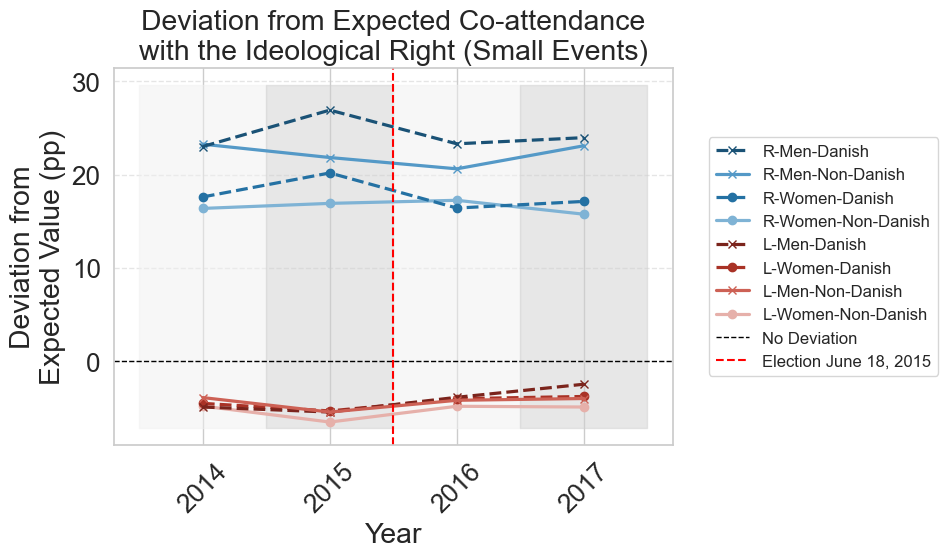

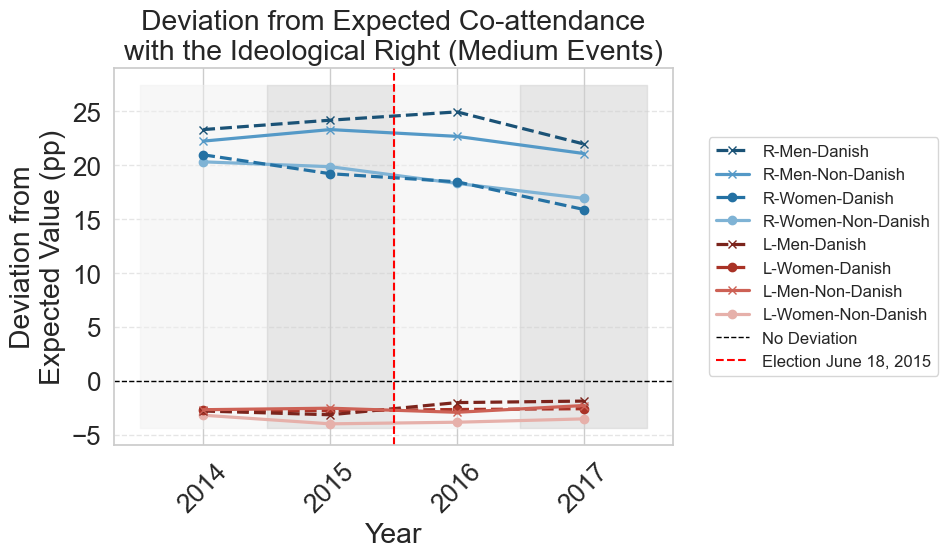

In [6]:
SUBGROUP_RENAME = {
    'Danish-M-L':     'L-Men-Danish',
    'Danish-F-L':     'L-Women-Danish',
    'Non-Danish-M-L': 'L-Men-Non-Danish',
    'Non-Danish-F-L': 'L-Women-Non-Danish',
    'Danish-M-R':     'R-Men-Danish',
    'Danish-F-R':     'R-Women-Danish',
    'Non-Danish-M-R': 'R-Men-Non-Danish',
    'Non-Danish-F-R': 'R-Women-Non-Danish',
}

SUBGROUP_STYLES = {
    'L-Men-Danish':      {'color': '#7B241C', 'marker': 'x', 'linestyle': '--'},
    'L-Women-Danish':    {'color': '#A93226', 'marker': 'o', 'linestyle': '--'},
    'L-Men-Non-Danish':  {'color': '#CD6155', 'marker': 'x', 'linestyle': '-'},
    'L-Women-Non-Danish':{'color': '#E6B0AA', 'marker': 'o', 'linestyle': '-'},
    'R-Men-Danish':      {'color': '#1A5276', 'marker': 'x', 'linestyle': '--'},
    'R-Women-Danish':    {'color': '#2471A3', 'marker': 'o', 'linestyle': '--'},
    'R-Men-Non-Danish':  {'color': '#5499C7', 'marker': 'x', 'linestyle': '-'},
    'R-Women-Non-Danish':{'color': '#7FB3D5', 'marker': 'o', 'linestyle': '-'},
}

LEGEND_ORDER = [
    'R-Men-Danish', 'R-Men-Non-Danish', 'R-Women-Danish', 'R-Women-Non-Danish',
    'L-Men-Danish', 'L-Women-Danish', 'L-Men-Non-Danish', 'L-Women-Non-Danish',
    'No Deviation', 'Election June 18, 2015',
]


def plot_subgroup_deviation(size_label, title, filename):
    # Collect data: {subgroup_label: {'x': [years], 'y': [deviations]}}
    series = {}
    for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
        year = int(period.split('-')[1])
        key  = f'{size_label}_{period}'
        for _, row in subgroup_stats[key].iterrows():
            label = SUBGROUP_RENAME.get(row['Subgroup'], row['Subgroup'])
            series.setdefault(label, {'x': [], 'y': []})
            series[label]['x'].append(year)
            series[label]['y'].append(row['% R Deviation'])

    all_y  = [v for s in series.values() for v in s['y']]
    y_min  = min(all_y) * 1.1
    y_max  = max(all_y) * 1.1

    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(len(SHADING_RANGES) - 1):
        ax.fill_betweenx([y_min, y_max], SHADING_RANGES[i], SHADING_RANGES[i+1],
                         color=SHADES[i % 2], alpha=0.5)

    for label, data in series.items():
        style = SUBGROUP_STYLES.get(label, {})
        xs    = np.array(data['x'])
        ys    = np.array(data['y'])
        ax.plot(xs[np.argsort(xs)], ys[np.argsort(xs)],
                marker=style.get('marker', 'o'),
                linestyle=style.get('linestyle', '-'),
                color=style.get('color', 'black'),
                label=label)

    ax.axhline(y=0, color='black', linewidth=1, linestyle='--', label='No Deviation')
    ax.axvline(x=ELECTION_YEAR, color='red', linestyle='--', linewidth=1.5,
               label='Election June 18, 2015')
    ax.set_xticks(YEARS)
    ax.set_xticklabels(YEARS, rotation=45)
    ax.set_xlabel('Year')
    ax.set_ylabel('Deviation from\nExpected Value (pp)')
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Ordered legend
    handles, labels = ax.get_legend_handles_labels()
    lmap    = dict(zip(labels, handles))
    ordered = [(lmap[l], l) for l in LEGEND_ORDER if l in lmap]
    ax.legend([h for h, _ in ordered], [l for _, l in ordered],
              loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=12)

    plt.tight_layout()
    plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


# Figure 7.6 — small events
plot_subgroup_deviation(
    'small',
    title='Deviation from Expected Co-attendance\nwith the Ideological Right (Small Events)',
    filename='figure_7_6_subgroup_deviation_small.png'
)

# Figure 7.7 — medium events
plot_subgroup_deviation(
    'medium',
    title='Deviation from Expected Co-attendance\nwith the Ideological Right (Medium Events)',
    filename='figure_7_7_subgroup_deviation_medium.png'
)

## 4. Gender and Heritage Breakdown — Figure E.4

Simpler marginal view: for each gender (M/F) and heritage (Danish/Non-Danish) group, what is the average deviation in right-leaning co-attendance across all political users of that demographic?

In [7]:

def compute_marginal_r_deviation(G, expected_r_pct, group_attr, valid_groups):
    """Per-group average deviation in % R co-attendance.

    Averages the per-user % R across all politically active users of each group.
    Matches Code3's per-user-mean approach.
    """
    group_pcts = {g: [] for g in valid_groups}

    for user in G.nodes():
        attrs    = G.nodes[user]
        group    = attrs.get(group_attr)
        ideology = attrs.get('l_r_min_max')

        if group not in valid_groups or ideology not in VALID_IDEOLOGY:
            continue

        l_w = r_w = 0
        for nbr, edge_data in G[user].items():
            nbr_ideology = G.nodes[nbr].get('l_r_min_max')
            w = edge_data.get('weight', 1)
            if nbr_ideology == 'L':
                l_w += w
            elif nbr_ideology == 'R':
                r_w += w

        total_pol = l_w + r_w
        if total_pol == 0:
            continue
        group_pcts[group].append(r_w / total_pol * 100)

    rows = []
    for g, pcts in group_pcts.items():
        if not pcts:
            continue
        avg_r = np.mean(pcts)
        rows.append({
            'Group':          g,
            'Average R (%)':  round(avg_r, 2),
            'Expected R (%)': round(expected_r_pct, 2),
            'Deviation R (%)':round(avg_r - expected_r_pct, 2),
        })
    return pd.DataFrame(rows)


gender_dev   = {k: compute_marginal_r_deviation(user_graphs[k], expected_r[k],
                                                'gender_label',   ['M', 'F'])            for k in KEYS}
heritage_dev = {k: compute_marginal_r_deviation(user_graphs[k], expected_r[k],
                                                'heritage_label', ['Danish', 'Non-Danish']) for k in KEYS}

print("Gender deviation sample (small_2013-2014):")
print(gender_dev['small_2013-2014'])
print("\nHeritage deviation sample (small_2013-2014):")
print(heritage_dev['small_2013-2014'])


Gender deviation sample (small_2013-2014):
  Group  Average R (%)  Expected R (%)  Deviation R (%)
0     M          20.60           17.85             2.75
1     F          16.44           17.85            -1.40

Heritage deviation sample (small_2013-2014):
        Group  Average R (%)  Expected R (%)  Deviation R (%)
0      Danish          18.44           17.85             0.59
1  Non-Danish          17.57           17.85            -0.28


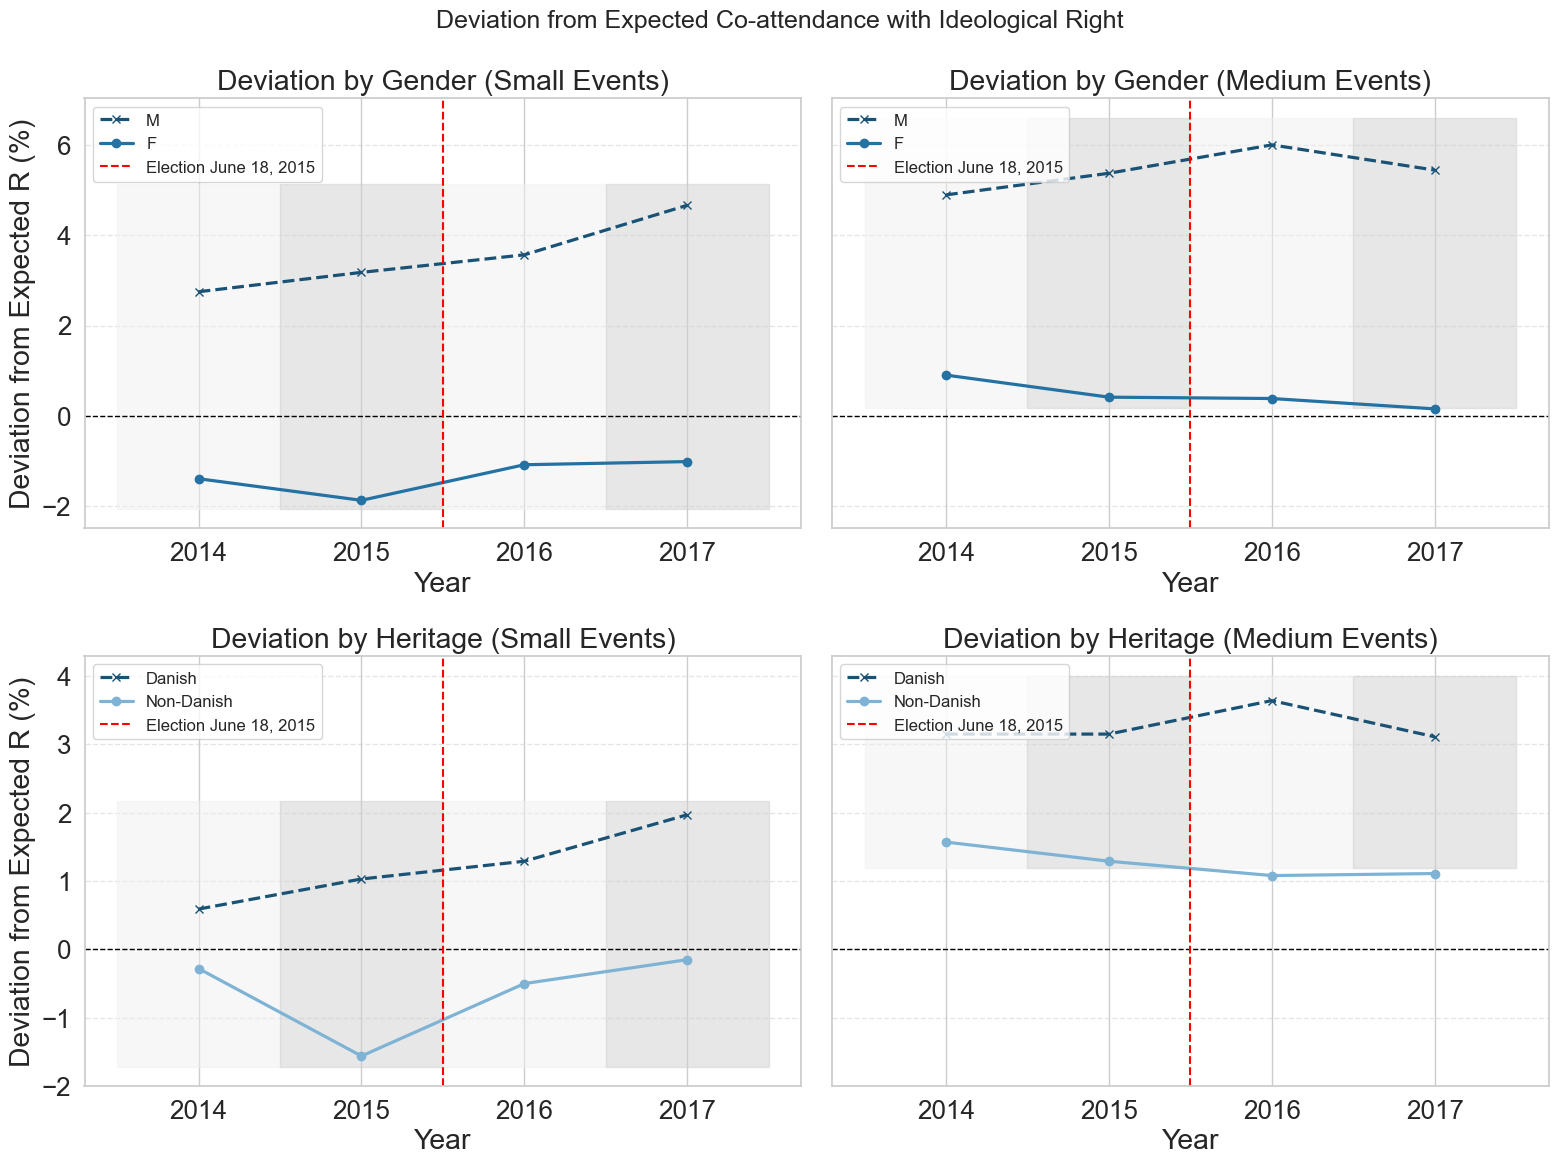

In [8]:
def extract_marginal_series(stats_dict, group_col, size_label):
    """Extract {group: {x: [years], y: [deviations]}} for one event size."""
    series = {}
    for period in ['2013-2014', '2014-2015', '2015-2016', '2016-2017']:
        year = int(period.split('-')[1])
        key  = f'{size_label}_{period}'
        for _, row in stats_dict[key].iterrows():
            group = row[group_col]
            series.setdefault(group, {'x': [], 'y': []})
            series[group]['x'].append(year)
            series[group]['y'].append(row['Deviation R (%)'])
    return series


def plot_marginal_panel(ax, series, styles, size_label, title):
    all_y = [v for s in series.values() for v in s['y']]
    y_min, y_max = min(all_y) * 1.1, max(all_y) * 1.1

    for i in range(len(SHADING_RANGES) - 1):
        ax.fill_betweenx([y_min, y_max], SHADING_RANGES[i], SHADING_RANGES[i+1],
                         color=SHADES[i % 2], alpha=0.5)

    for group, data in series.items():
        style = styles.get(group, {})
        xs = np.array(data['x'])
        ys = np.array(data['y'])
        ax.plot(xs[np.argsort(xs)], ys[np.argsort(xs)],
                marker=style.get('marker', 'o'),
                linestyle=style.get('linestyle', '-'),
                color=style.get('color', 'grey'),
                label=group)

    ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
    ax.axvline(x=ELECTION_YEAR, color='red', linestyle='--', linewidth=1.5,
               label='Election June 18, 2015')
    ax.set_xticks(YEARS)
    ax.set_xlabel('Year')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)


gender_styles  = {
    'M': {'color': '#1A5276', 'marker': 'x', 'linestyle': '--'},
    'F': {'color': '#2471A3', 'marker': 'o', 'linestyle': '-'},
}
heritage_styles = {
    'Danish':     {'color': '#1A5276', 'marker': 'x', 'linestyle': '--'},
    'Non-Danish': {'color': '#7FB3D5', 'marker': 'o', 'linestyle': '-'},
}

# Figure E.4 — 2×2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharey='row')

plot_marginal_panel(axs[0, 0], extract_marginal_series(gender_dev, 'Group', 'small'),
                   gender_styles, 'small',
                   'Deviation by Gender (Small Events)')
plot_marginal_panel(axs[0, 1], extract_marginal_series(gender_dev, 'Group', 'medium'),
                   gender_styles, 'medium',
                   'Deviation by Gender (Medium Events)')
plot_marginal_panel(axs[1, 0], extract_marginal_series(heritage_dev, 'Group', 'small'),
                   heritage_styles, 'small',
                   'Deviation by Heritage (Small Events)')
plot_marginal_panel(axs[1, 1], extract_marginal_series(heritage_dev, 'Group', 'medium'),
                   heritage_styles, 'medium',
                   'Deviation by Heritage (Medium Events)')

axs[0, 0].set_ylabel('Deviation from Expected R (%)')
axs[1, 0].set_ylabel('Deviation from Expected R (%)')
fig.suptitle('Deviation from Expected Co-attendance with Ideological Right', fontsize=18)

plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_e4_marginal_deviation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. KDE Plots — Ego vs. Average Alter Ideology

For each politically-active user, compute:
- **ego score**: their own normalised ideology (`normalized_min_max`)
- **average alter score**: the weighted average ideology of their ego network, where weights are edge weights (number of co-attended events)

The KDE visualises the joint density of these two values across all users in each time period.

In [9]:
def compute_ego_alter_df(G, filter_fn=None):
    """Build a DataFrame of (ego_score, avg_alter_score) for each qualifying node.

    Args:
        filter_fn: optional function(node_attrs) -> bool to restrict ego nodes.
    """
    rows = []
    for node in G.nodes():
        attrs     = G.nodes[node]
        ego_score = attrs.get('normalized_min_max')

        if ego_score is None or pd.isna(ego_score):
            continue
        if filter_fn is not None and not filter_fn(attrs):
            continue

        weighted_sum = 0.0
        total_weight = 0.0
        for nbr, edge_data in G[node].items():
            nbr_score = G.nodes[nbr].get('normalized_min_max')
            if nbr_score is None or pd.isna(nbr_score):
                continue
            w = edge_data.get('weight', 1)
            weighted_sum += nbr_score * w
            total_weight += w

        if total_weight == 0:
            continue

        rows.append({
            'ego_score':          ego_score,
            'avg_neighbor_score': weighted_sum / total_weight,
        })

    return pd.DataFrame(rows).dropna()


# Compute ego-alter DataFrames for all users and Danish men, for all datasets
PERIODS = ['2013-2014', '2014-2015', '2015-2016', '2016-2017']

all_user_dfs    = {k: {} for k in ['small', 'medium']}
danish_men_dfs  = {k: {} for k in ['small', 'medium']}

danish_men_filter = lambda a: a.get('gender_label') == 'M' and a.get('heritage_label') == 'Danish'

for key in KEYS:
    size   = 'small' if 'small' in key else 'medium'
    period = key.replace(f'{size}_', '')
    G      = user_graphs[key]

    print(f"{key}...")
    all_user_dfs[size][period]   = compute_ego_alter_df(G)
    danish_men_dfs[size][period] = compute_ego_alter_df(G, filter_fn=danish_men_filter)

    print(f"  All users: {len(all_user_dfs[size][period]):,} | Danish men: {len(danish_men_dfs[size][period]):,}")

small_2013-2014...


  All users: 14,090 | Danish men: 3,556
small_2014-2015...


  All users: 16,373 | Danish men: 3,847
small_2015-2016...


  All users: 21,951 | Danish men: 4,959
small_2016-2017...


  All users: 24,597 | Danish men: 5,642
medium_2013-2014...


  All users: 25,355 | Danish men: 6,452
medium_2014-2015...


  All users: 30,822 | Danish men: 7,430
medium_2015-2016...


  All users: 38,081 | Danish men: 9,038
medium_2016-2017...


  All users: 37,386 | Danish men: 8,853


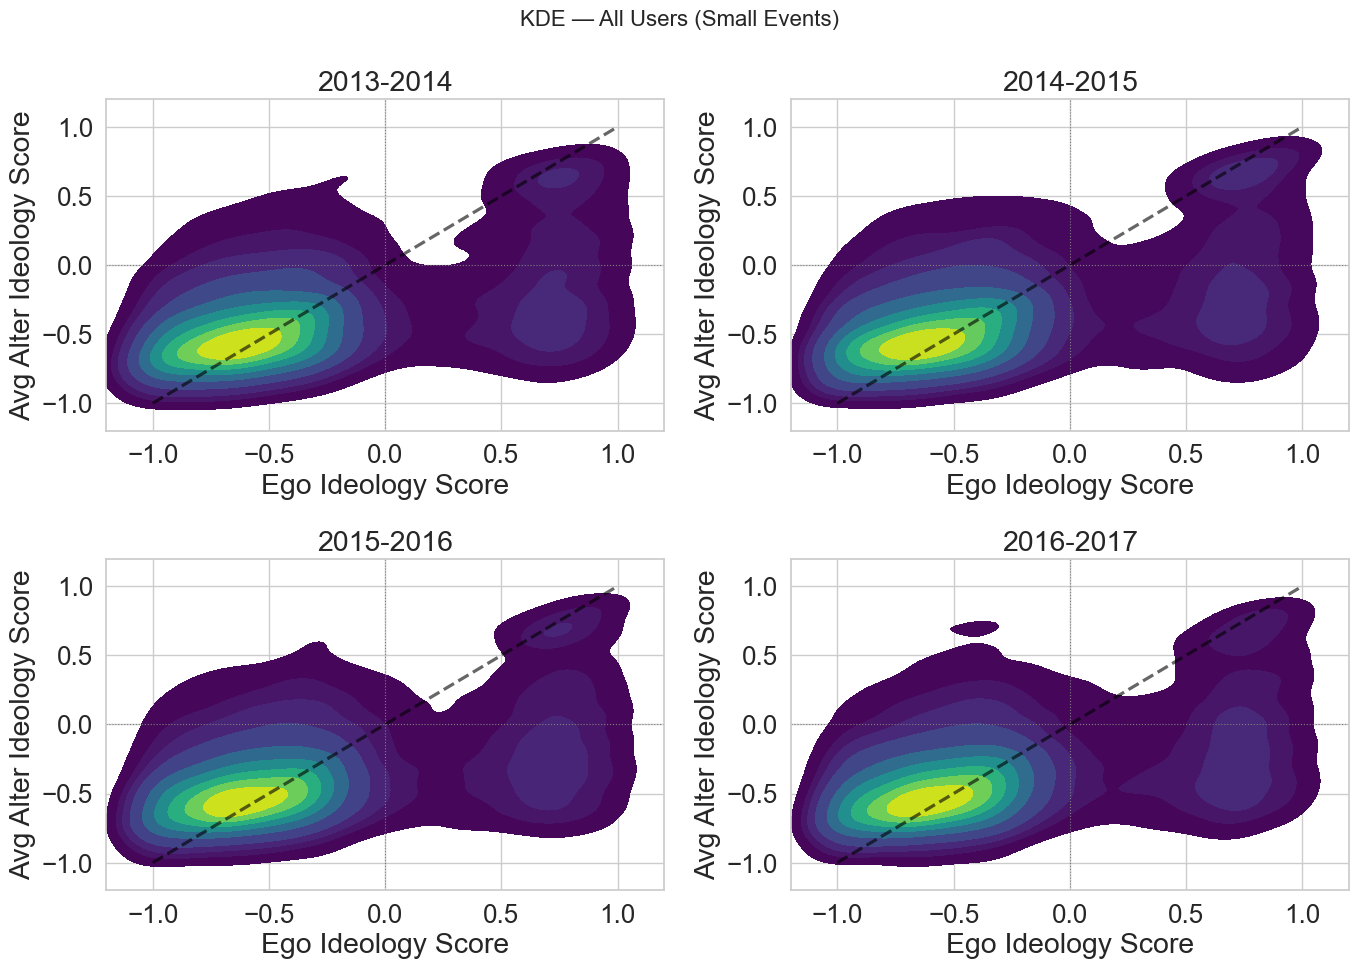

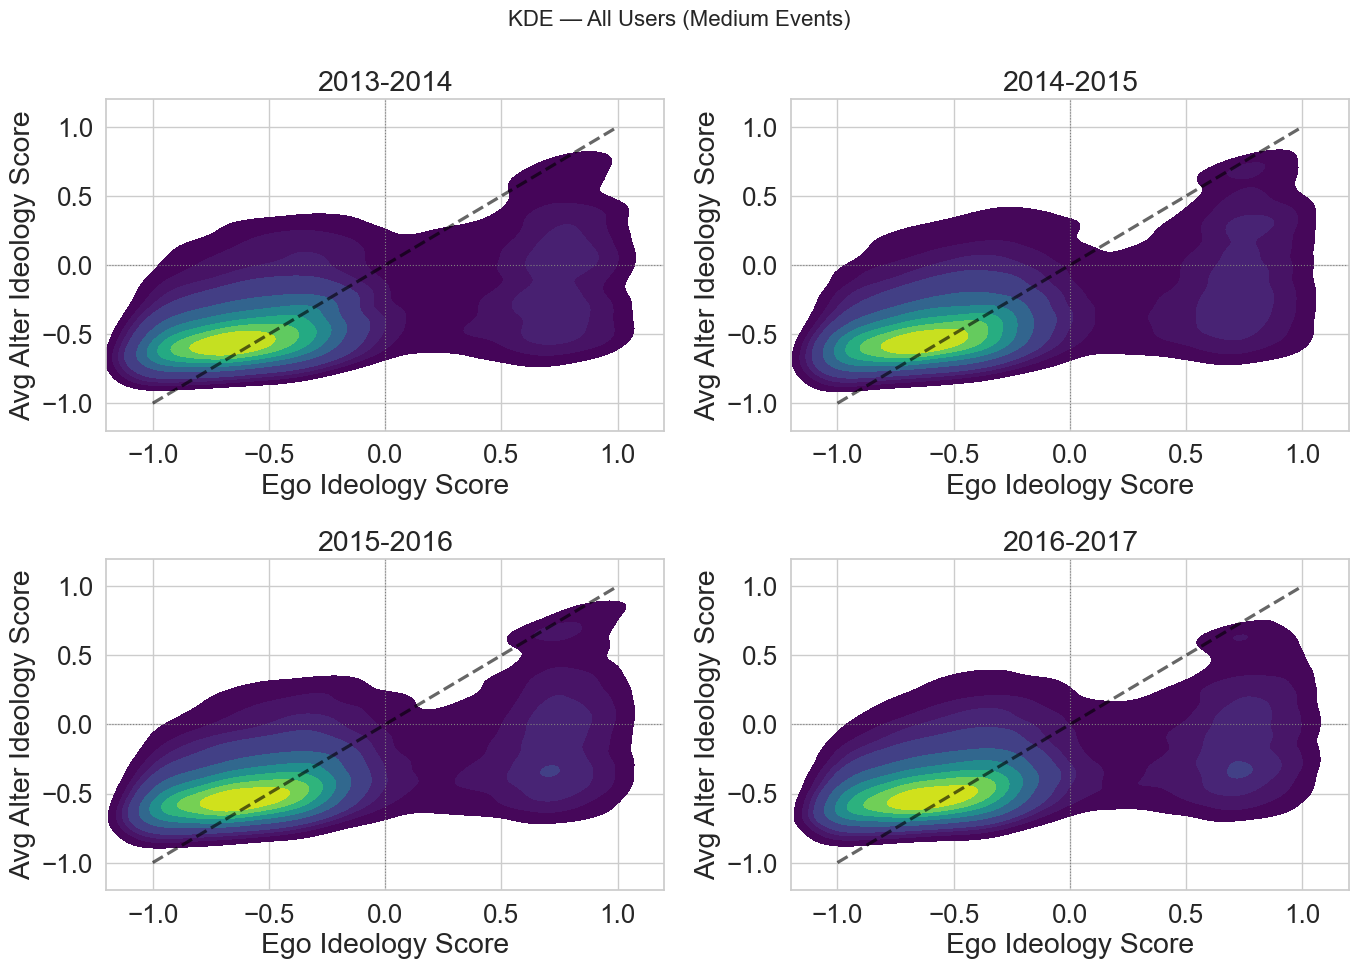

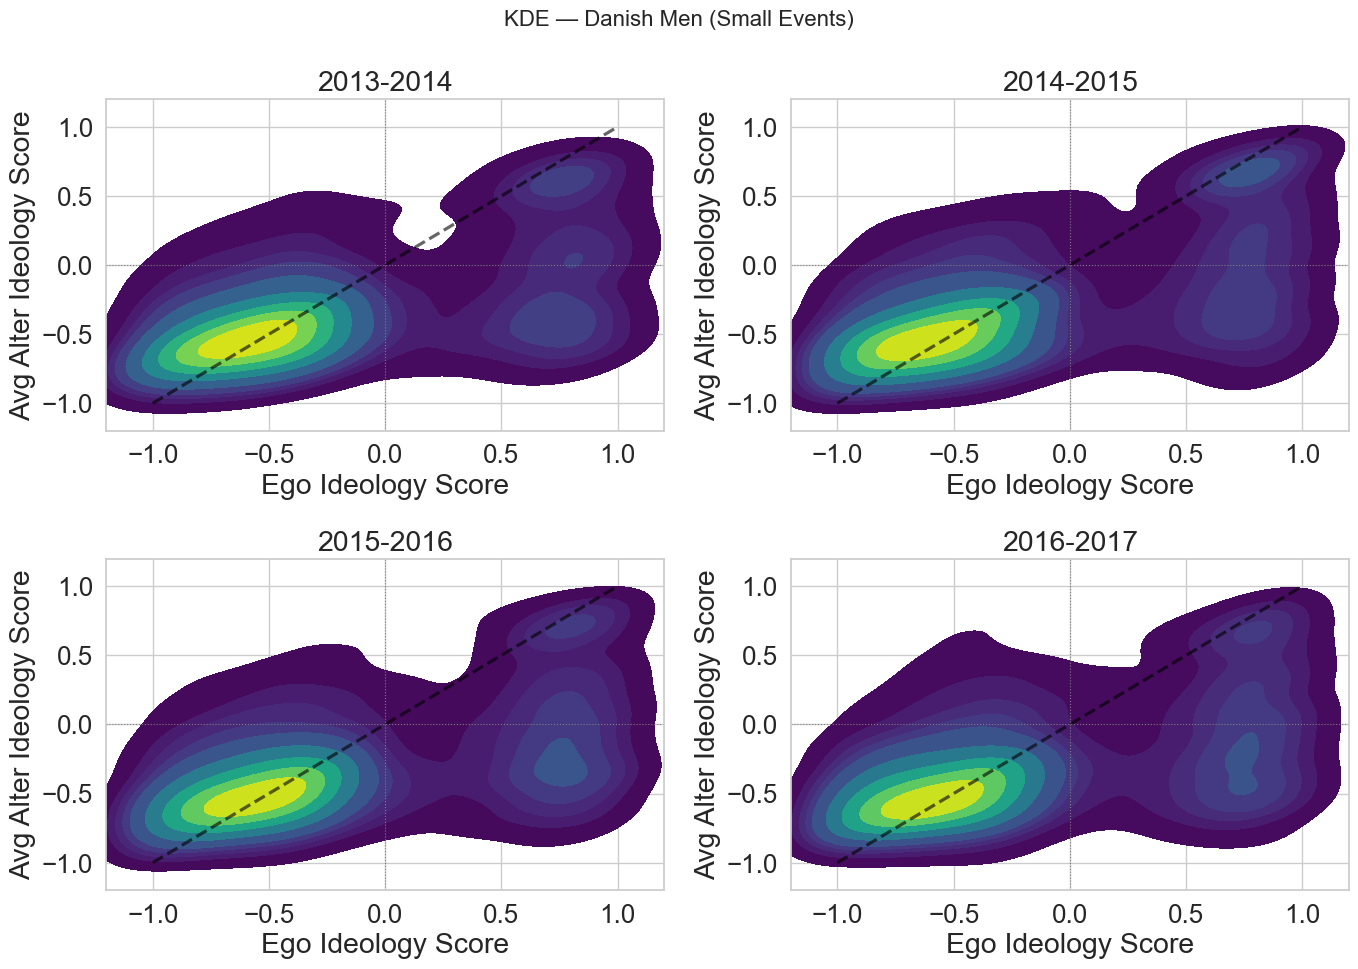

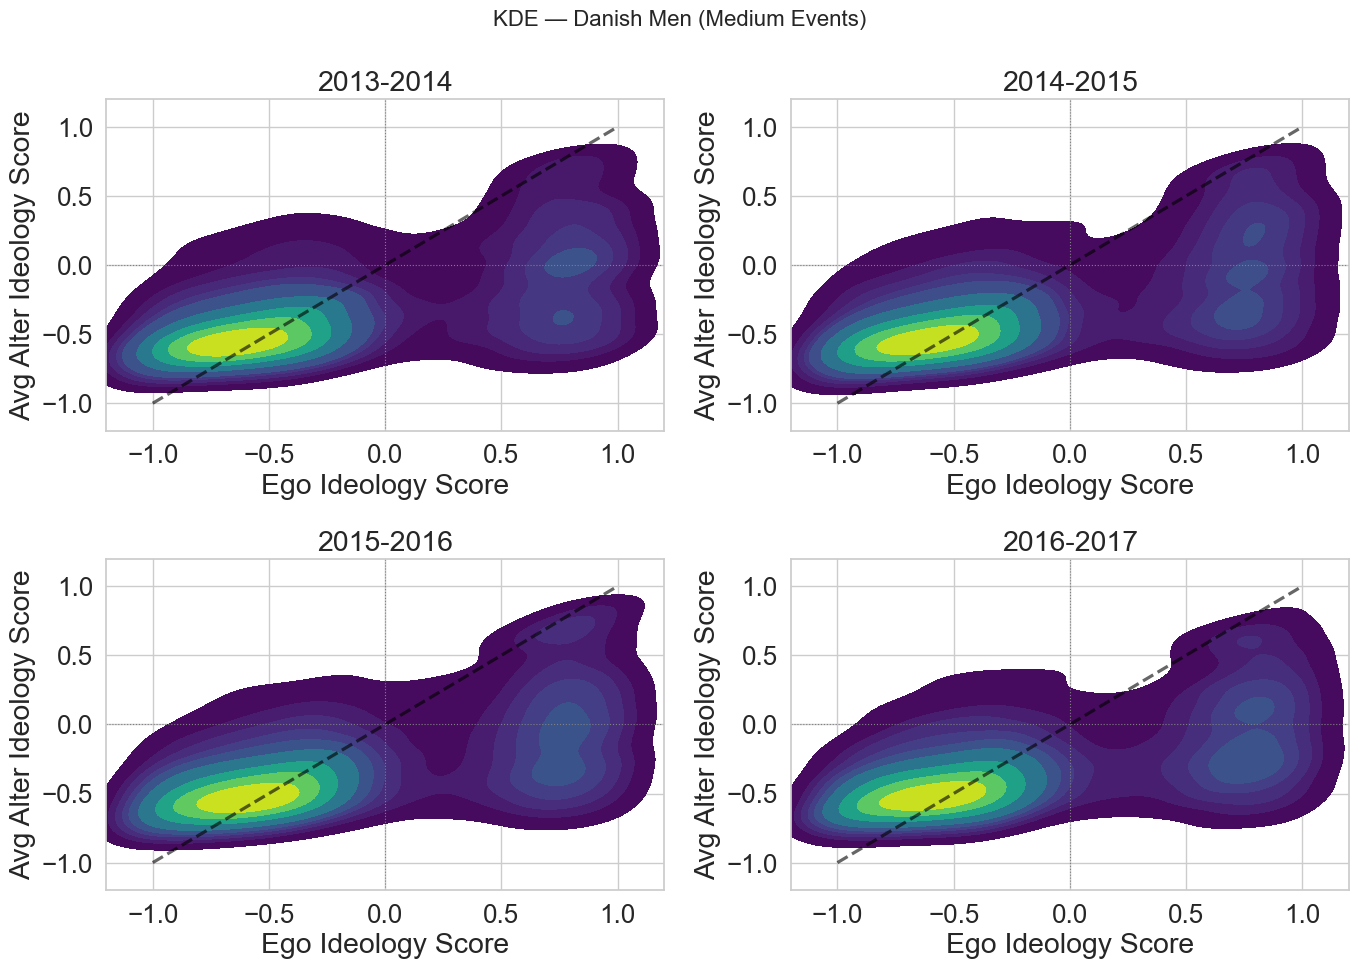

In [10]:
def plot_kde_grid(df_dict, title, filename):
    """Plot a 2x2 grid of KDE plots, one panel per time period."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes      = axes.flatten()

    for ax, period in zip(axes, PERIODS):
        df = df_dict.get(period, pd.DataFrame())
        if df.empty:
            ax.set_visible(False)
            continue

        sns.kdeplot(
            data=df, x='ego_score', y='avg_neighbor_score',
            fill=True, cmap='viridis', levels=10, thresh=0.05, ax=ax
        )
        ax.plot([-1, 1], [-1, 1], linestyle='--', color='black', alpha=0.6)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
        ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
        ax.set_title(period)
        ax.set_xlabel('Ego Ideology Score')
        ax.set_ylabel('Avg Alter Ideology Score')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


# Figures E.5–E.8
plot_kde_grid(all_user_dfs['small'],   'KDE — All Users (Small Events)',         'figure_e5_kde_all_small.png')
plot_kde_grid(all_user_dfs['medium'],  'KDE — All Users (Medium Events)',        'figure_e6_kde_all_medium.png')
plot_kde_grid(danish_men_dfs['small'], 'KDE — Danish Men (Small Events)',        'figure_e7_kde_danish_men_small.png')
plot_kde_grid(danish_men_dfs['medium'],'KDE — Danish Men (Medium Events)',       'figure_e8_kde_danish_men_medium.png')

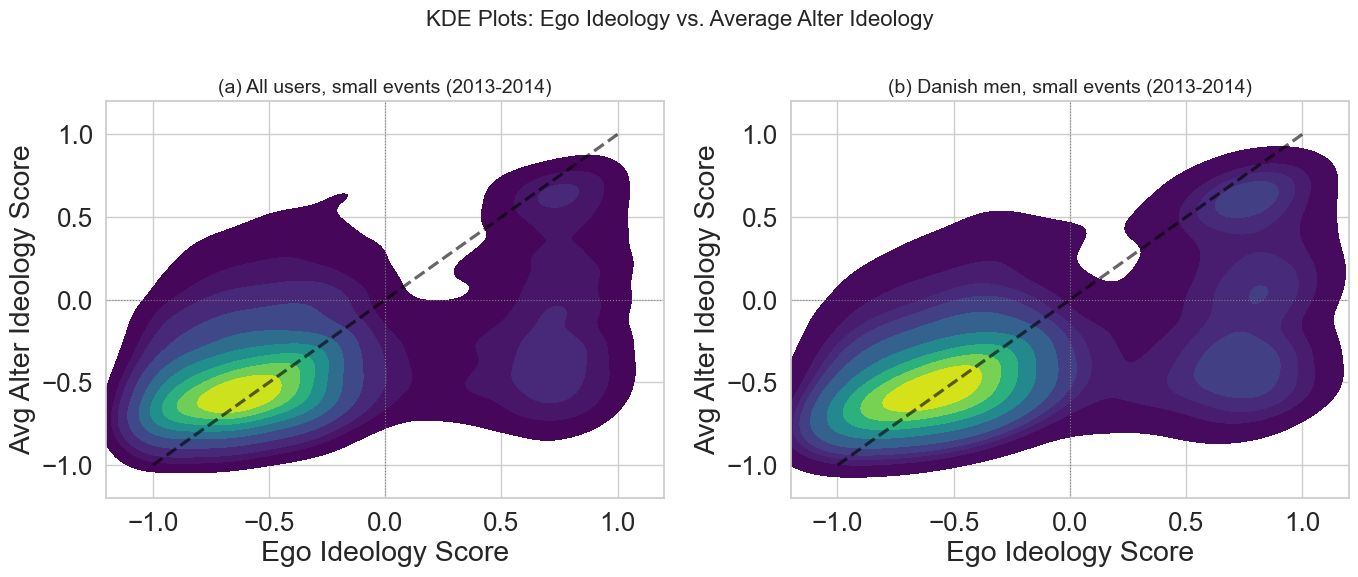

In [11]:
# Figure 7.8 — two-panel: all users + Danish men, small events 2013-2014

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, subtitle) in zip(axes, [
    (all_user_dfs['small']['2013-2014'],    '(a) All users, small events (2013-2014)'),
    (danish_men_dfs['small']['2013-2014'],  '(b) Danish men, small events (2013-2014)'),
]):
    sns.kdeplot(
        data=df, x='ego_score', y='avg_neighbor_score',
        fill=True, cmap='viridis', levels=10, thresh=0.05, ax=ax
    )
    ax.plot([-1, 1], [-1, 1], linestyle='--', color='black', alpha=0.6)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(subtitle, fontsize=14)
    ax.set_xlabel('Ego Ideology Score')
    ax.set_ylabel('Avg Alter Ideology Score')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle('KDE Plots: Ego Ideology vs. Average Alter Ideology', fontsize=16)
plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_7_8_kde_2013_2014.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Figure 5.1 — Demographic Distributions of Unique Users

Four pie charts showing the overall trait distribution of the unique user population across all datasets: political activity, L/R ideology (for political users), heritage, and gender.

Unique users: 494,684
  Political:     88,395 (17.9%)
  Non-political: 406,289
  L: 64,080 | R: 24,315


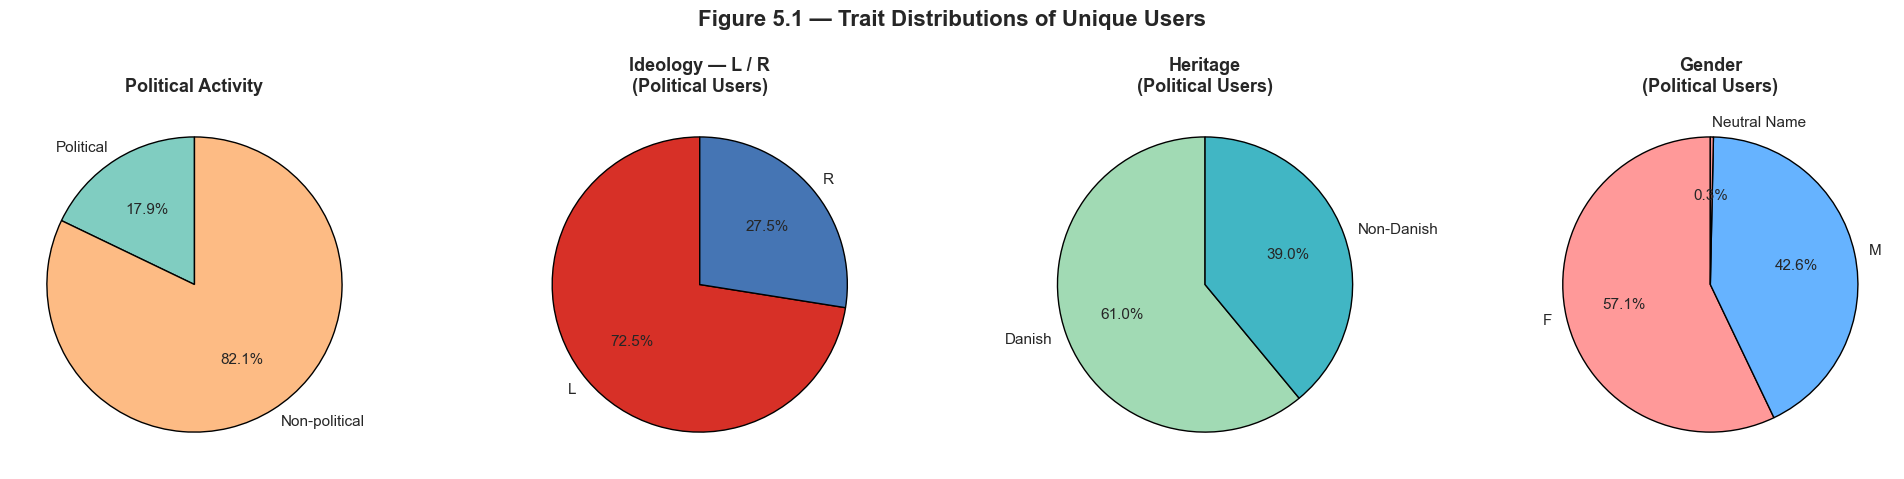

In [12]:

# Unique users across all period/size combinations (deduplicated by hashed_id)
all_users_combined = pd.concat(filtered_users.values(), ignore_index=True)
unique_users = all_users_combined.drop_duplicates(subset='hashed_id')

# Distributions
gender_counts   = unique_users['gender_label'].value_counts(dropna=True)
heritage_counts = unique_users['heritage_label'].value_counts(dropna=True)
n_political     = unique_users['political'].sum()
n_non_political = len(unique_users) - n_political
scored          = unique_users[unique_users['political']]
l_count         = (scored['l_r_min_max'] == 'L').sum()
r_count         = (scored['l_r_min_max'] == 'R').sum()

print(f"Unique users: {len(unique_users):,}")
print(f"  Political:     {n_political:,} ({n_political/len(unique_users)*100:.1f}%)")
print(f"  Non-political: {n_non_political:,}")
print(f"  L: {l_count:,} | R: {r_count:,}")

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
text_props = {'fontsize': 11}
font_settings = {'fontsize': 13, 'fontweight': 'bold'}

axs[0].pie(
    [n_political, n_non_political],
    labels=['Political', 'Non-political'],
    autopct='%1.1f%%', startangle=90,
    colors=['#80cdc1', '#fdbb84'], textprops=text_props,
    wedgeprops={'edgecolor': 'black'}
)
axs[0].set_title('Political Activity', fontdict=font_settings)

axs[1].pie(
    [l_count, r_count], labels=['L', 'R'],
    autopct='%1.1f%%', startangle=90,
    colors=['#d73027', '#4575b4'], textprops=text_props,
    wedgeprops={'edgecolor': 'black'}
)
axs[1].set_title('Ideology — L / R\n(Political Users)', fontdict=font_settings)

axs[2].pie(
    heritage_counts.values, labels=heritage_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#a1dab4', '#41b6c4'], textprops=text_props,
    wedgeprops={'edgecolor': 'black'}
)
axs[2].set_title('Heritage\n(Political Users)', fontdict=font_settings)

scored_gender = scored['gender_label'].value_counts(dropna=True)
axs[3].pie(
    scored_gender.values, labels=scored_gender.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#ff9999', '#66b3ff'], textprops=text_props,
    wedgeprops={'edgecolor': 'black'}
)
axs[3].set_title('Gender\n(Political Users)', fontdict=font_settings)

fig.suptitle('Figure 5.1 — Trait Distributions of Unique Users', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_5_1_demographic_pies.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Appendix A — Distribution Plots

Descriptive statistics and distribution plots for the event and user datasets.

### Figure A.1 — Distribution of Events Attended Per User (log-scaled)
### Figure A.2 — Distribution of Weighted Event Ideology Scores
### Figures A.3 / A.4 — Normalised User Ideology Scores (small / medium events)
### Figures A.5 / A.6 — Attendee Count Distributions (small / medium events)
### Figures A.7 / A.8 — Degree Distributions of Event-Event Networks
### Figure A.9 — Attendees Per Event: Total vs Politically Active

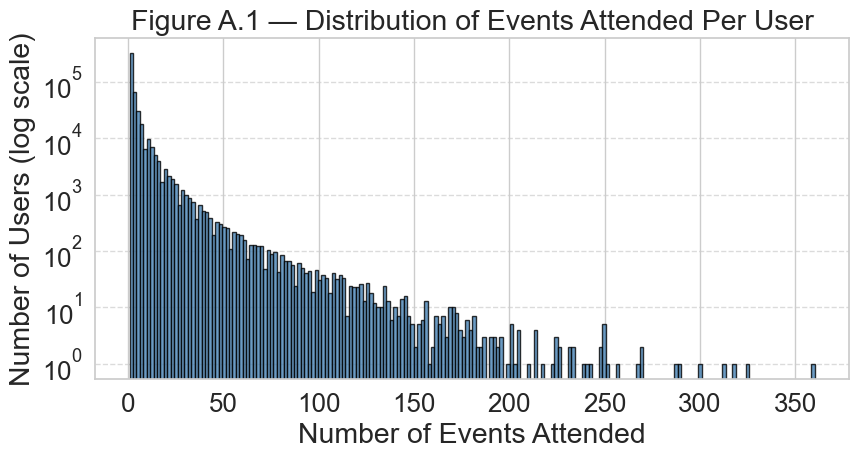

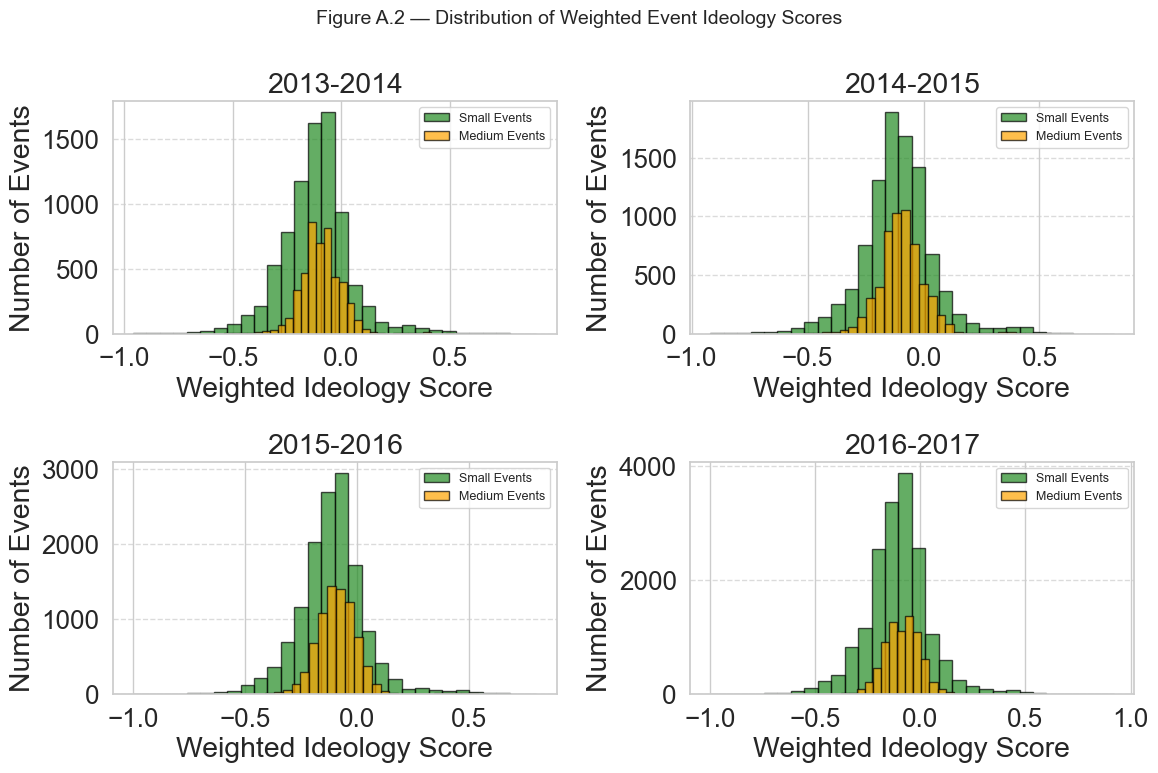

/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('bin').size().reset_index(name='count')
/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('bin').size().reset_index(name='count')
/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('b

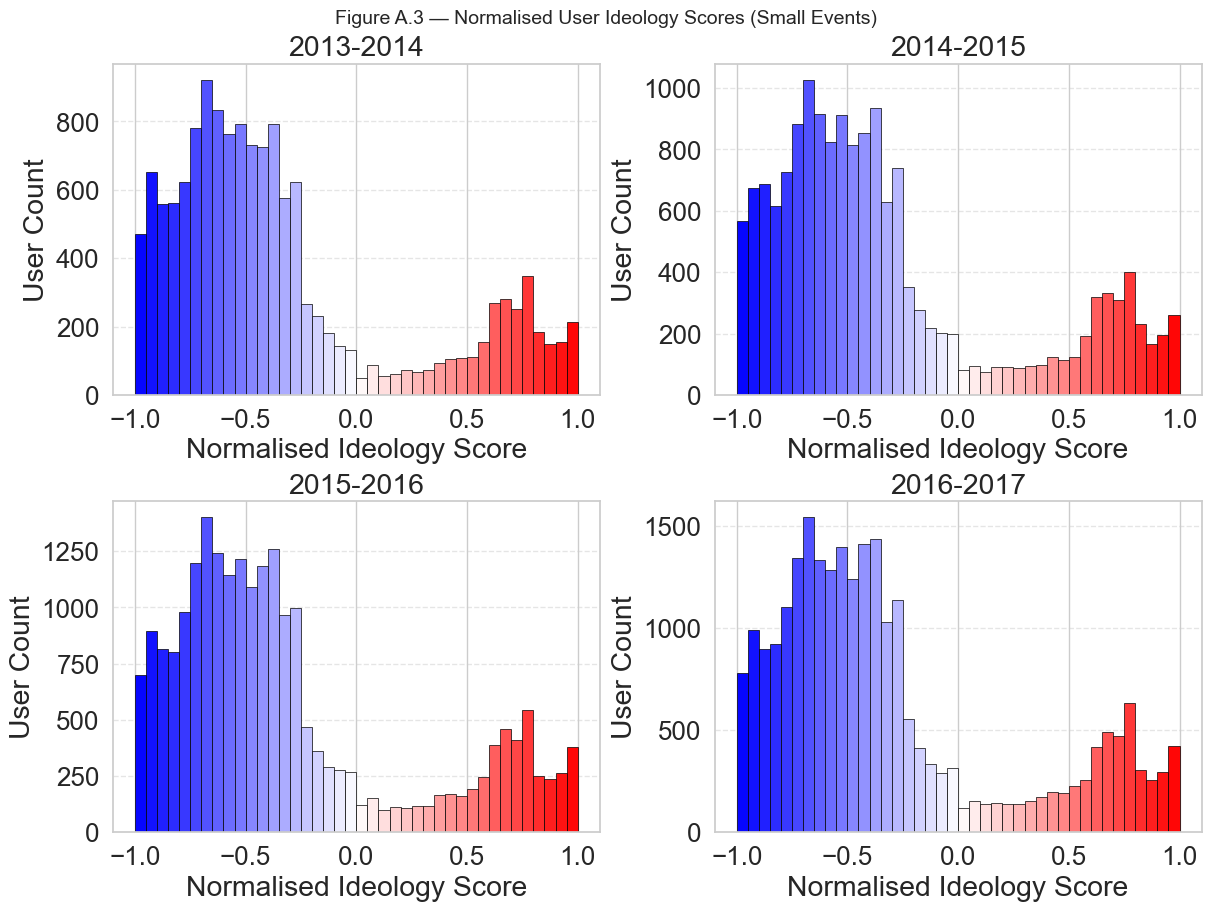

/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('bin').size().reset_index(name='count')
/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('bin').size().reset_index(name='count')
/tmp/claude-501/ipykernel_81762/1536184026.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hist = df.groupby('b

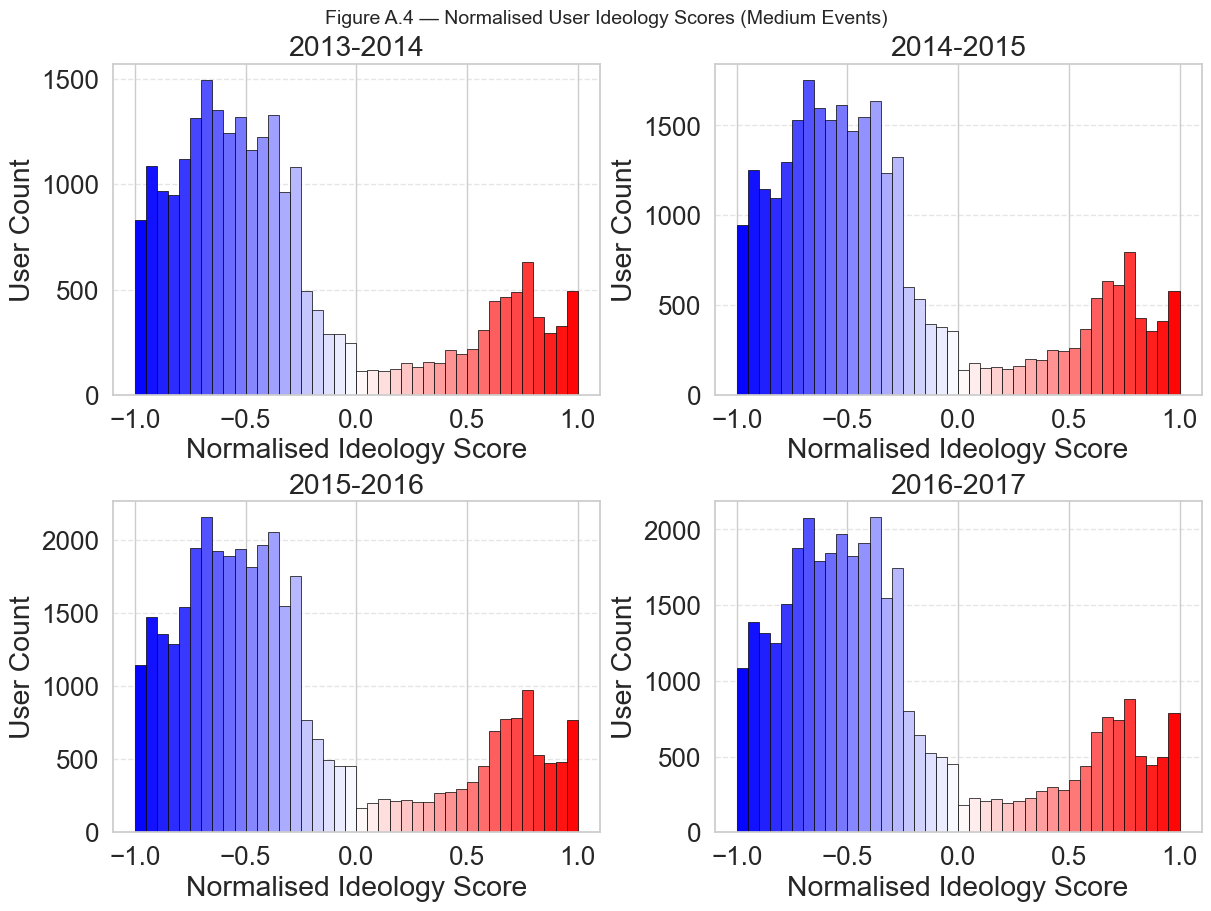

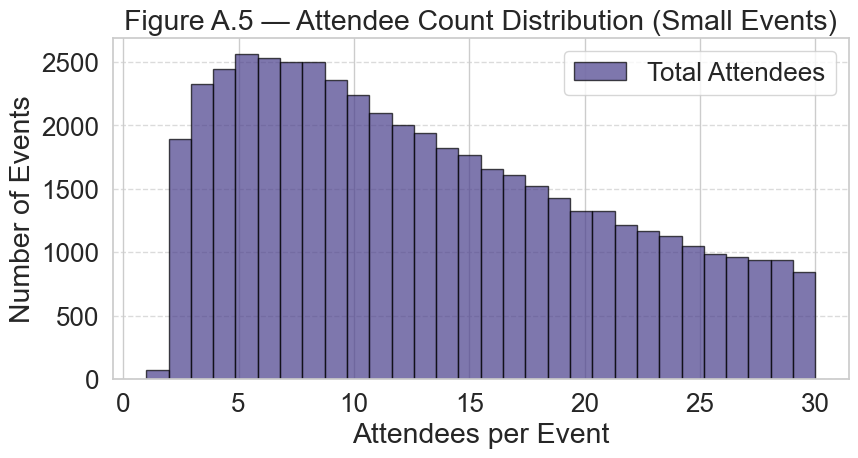

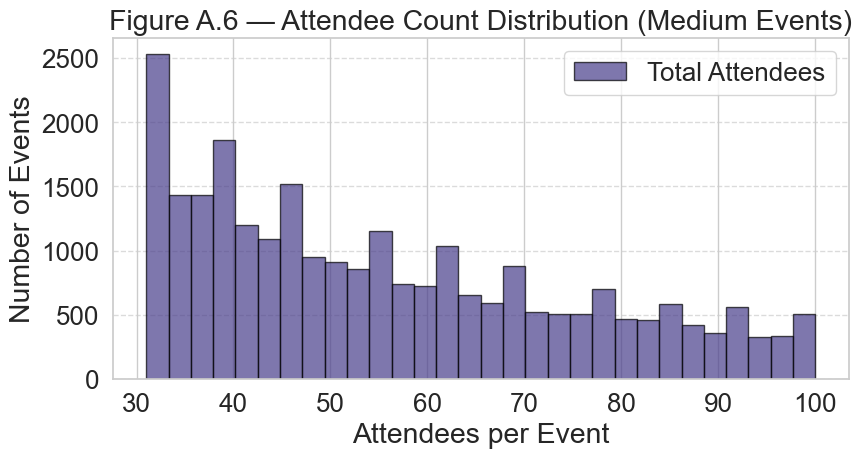

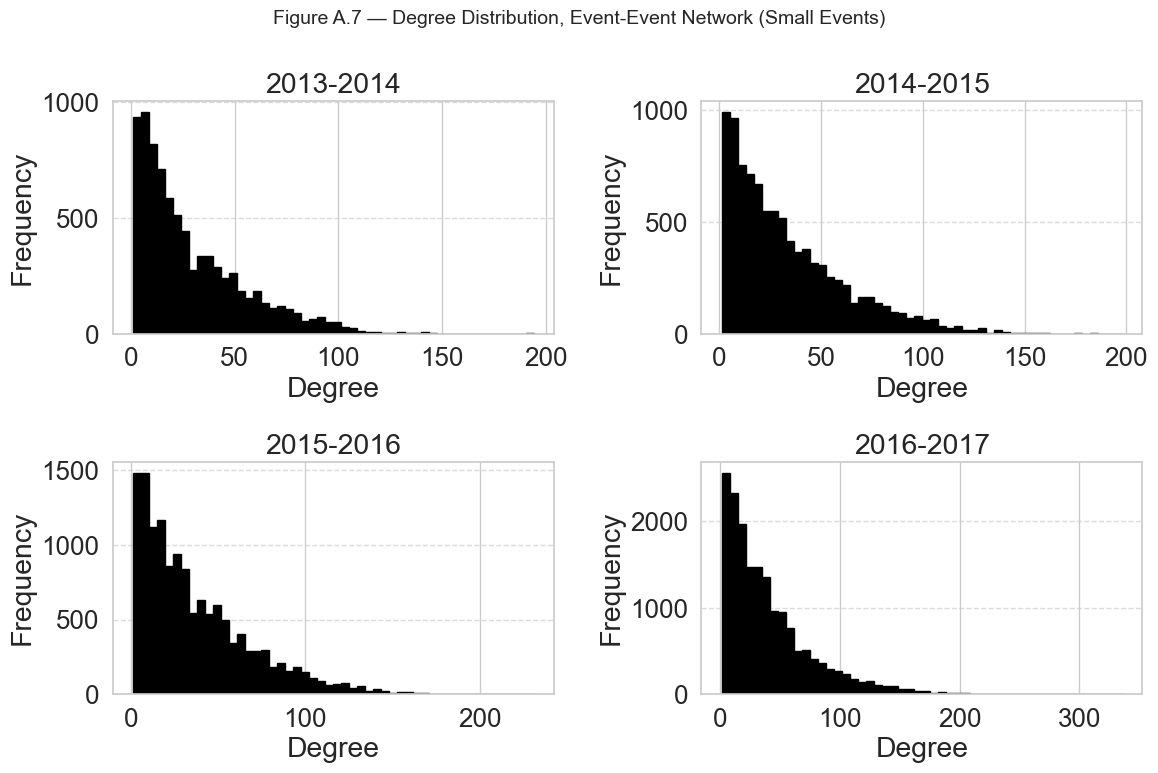

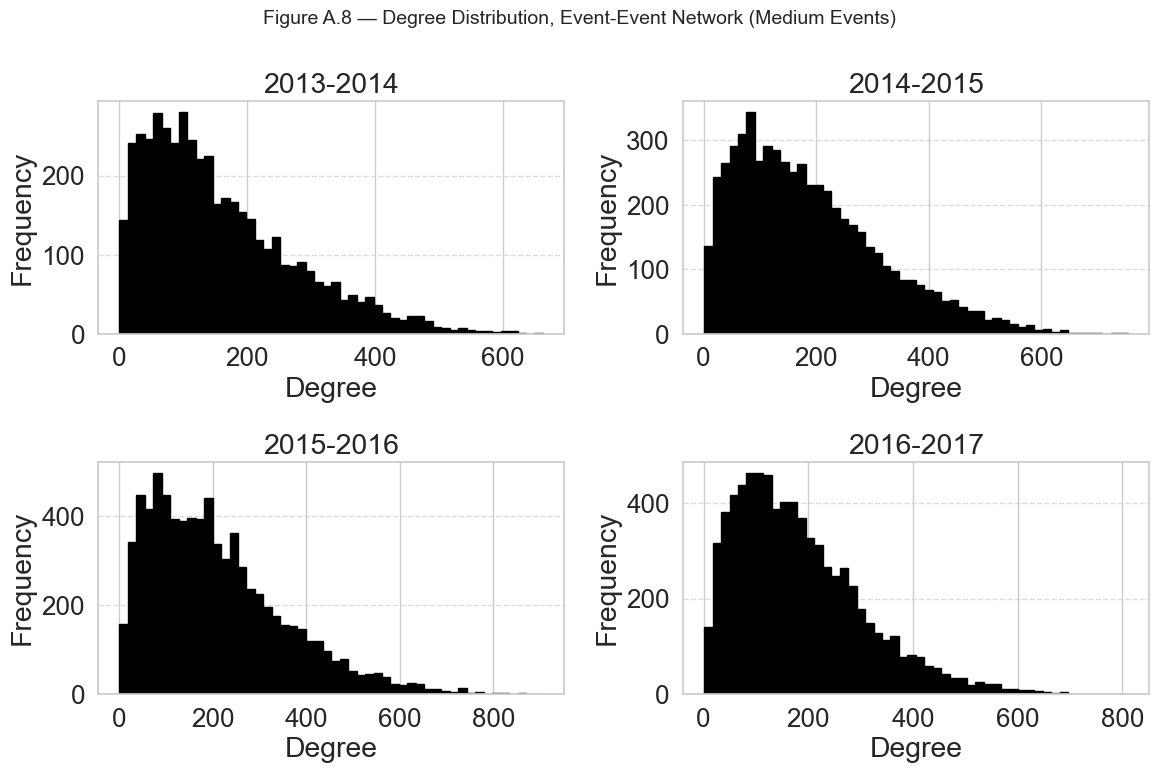

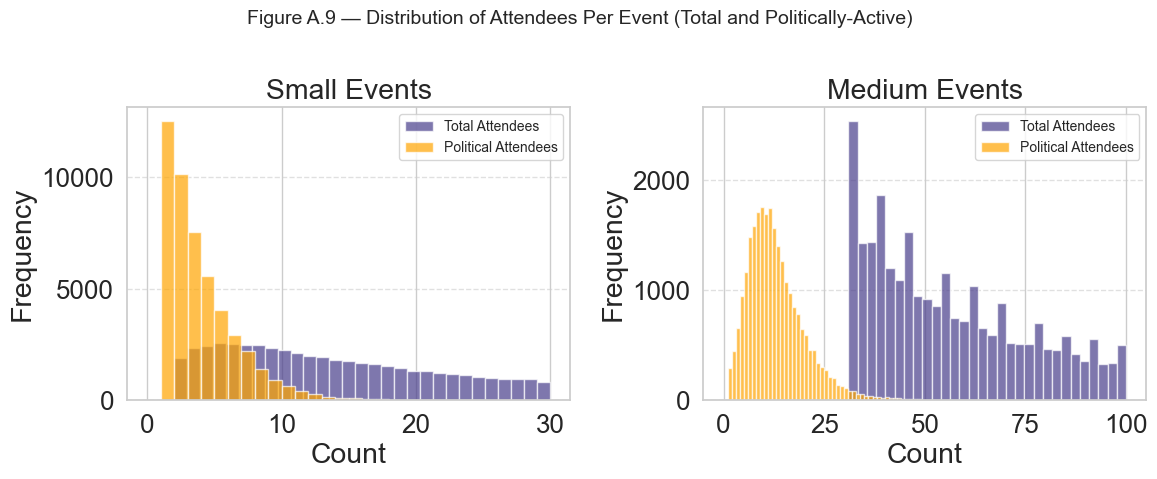

In [13]:

from collections import Counter
import matplotlib.colors as mcolors

# ── Figure A.1: Events attended per user (log scale) ──────────────────────────
user_event_counts = Counter()
for evts_df in filtered_events.values():
    for attendees in evts_df['attending']:
        for uid in attendees:
            user_event_counts[uid] += 1

event_count_values = list(user_event_counts.values())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(event_count_values, bins=200, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Number of Events Attended')
ax.set_ylabel('Number of Users (log scale)')
ax.set_title('Figure A.1 — Distribution of Events Attended Per User')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_a1_events_per_user.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure A.2: Weighted event ideology scores (2×2 per period) ───────────────
PERIODS = ['2013-2014', '2014-2015', '2015-2016', '2016-2017']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, period in zip(axes.flatten(), PERIODS):
    small  = filtered_events[f'small_{period}']['weighted_ideology_min_max'].dropna()
    medium = filtered_events[f'medium_{period}']['weighted_ideology_min_max'].dropna()
    ax.hist(small,  bins=30, alpha=0.7, label='Small Events',  color='forestgreen', edgecolor='black')
    ax.hist(medium, bins=30, alpha=0.7, label='Medium Events', color='orange',      edgecolor='black')
    ax.set_title(period)
    ax.set_xlabel('Weighted Ideology Score')
    ax.set_ylabel('Number of Events')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
fig.suptitle('Figure A.2 — Distribution of Weighted Event Ideology Scores', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_a2_event_ideology_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figures A.3 / A.4: User ideology score distributions ─────────────────────
bins_ideo  = pd.IntervalIndex.from_breaks([-(20 - i) / 20 for i in range(41)])
bin_labels = [(b.left + b.right) / 2 for b in bins_ideo]
norm_ideo  = mcolors.Normalize(vmin=-1, vmax=1)
cmap_ideo  = plt.get_cmap('bwr')

def plot_user_ideology_grid(size_label, fig_title, filename):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    for ax, period in zip(axes.flatten(), PERIODS):
        key = f'{size_label}_{period}'
        df  = filtered_users[key][['normalized_min_max']].dropna()
        df['bin'] = pd.cut(df['normalized_min_max'], bins_ideo).cat.rename_categories(bin_labels)
        hist = df.groupby('bin').size().reset_index(name='count')
        hist['bin'] = hist['bin'].astype(float)
        ax.bar(hist['bin'], hist['count'], width=0.05,
               color=[cmap_ideo(norm_ideo(v)) for v in hist['bin']],
               edgecolor='black', linewidth=0.5)
        ax.set_title(period)
        ax.set_xlabel('Normalised Ideology Score')
        ax.set_ylabel('User Count')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    fig.suptitle(fig_title, fontsize=14)
    plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_user_ideology_grid('small',  'Figure A.3 — Normalised User Ideology Scores (Small Events)', 'figure_a3_user_ideology_small.png')
plot_user_ideology_grid('medium', 'Figure A.4 — Normalised User Ideology Scores (Medium Events)', 'figure_a4_user_ideology_medium.png')

# ── Figures A.5 / A.6: Attendee count distributions ──────────────────────────
for size_label, fig_num in [('small', 'A.5'), ('medium', 'A.6')]:
    all_events = pd.concat(
        [filtered_events[f'{size_label}_{p}'] for p in PERIODS], ignore_index=True
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(all_events['n_attending'], bins=30, alpha=0.7, color='darkslateblue',
            label='Total Attendees', edgecolor='black')
    ax.set_xlabel('Attendees per Event')
    ax.set_ylabel('Number of Events')
    ax.set_title(f'Figure {fig_num} — Attendee Count Distribution ({size_label.title()} Events)')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'figure_{fig_num.lower().replace(".", "_")}_attendee_counts_{size_label}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# ── Figures A.7 / A.8: Degree distributions of event-event networks ───────────
event_graphs_loaded = {k: load_pkl(DATA_DIR / f'event_graph_{k}.pkl') for k in KEYS}

def plot_degree_grid(size_label, fig_title, filename):
    keys = [k for k in KEYS if k.startswith(size_label)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, key in zip(axes.flatten(), keys):
        G = event_graphs_loaded[key]
        degrees = [d for _, d in G.degree()]
        ax.hist(degrees, bins=50, color='black', edgecolor='black')
        ax.set_title(key.replace(f'{size_label}_', ''))
        ax.set_xlabel('Degree')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout()
    plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_degree_grid('small',  'Figure A.7 — Degree Distribution, Event-Event Network (Small Events)',
                 'figure_a7_degree_dist_small.png')
plot_degree_grid('medium', 'Figure A.8 — Degree Distribution, Event-Event Network (Medium Events)',
                 'figure_a8_degree_dist_medium.png')

# ── Figure A.9: Total vs politically-active attendees ─────────────────────────
all_small  = pd.concat([filtered_events[f'small_{p}']  for p in PERIODS], ignore_index=True)
all_medium = pd.concat([filtered_events[f'medium_{p}'] for p in PERIODS], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, size_label in zip(axes, [all_small, all_medium], ['Small', 'Medium']):
    bins_pol = range(0, int(df['n_political_attending'].max()) + 2)
    ax.hist(df['n_attending'],          bins=30,       alpha=0.7, label='Total Attendees',    color='darkslateblue')
    ax.hist(df['n_political_attending'], bins=bins_pol, alpha=0.7, label='Political Attendees', color='orange')
    ax.set_title(f'{size_label} Events')
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
fig.suptitle('Figure A.9 — Distribution of Attendees Per Event (Total and Politically-Active)', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / 'figure_a9_attendees_per_event.png', dpi=150, bbox_inches='tight')
plt.show()
